# Import modules

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Read CSV file

In [3]:
pd.set_option("display.max_columns", 30)

In [4]:
df = pd.read_csv("../csv_files/ONINE_FOOD_DELIVERY_ANALYSIS.csv")
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Order_Time,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,NaN,Central,RES936,Restaurant_29,Chinese,10/20/2024,0:00,187.0,15.75,NaN,NaN,NaN,UPI,Delivered,NaN,DP563,5.0,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,NaN,Female,Chennai,North,RES689,Restaurant_419,Chinese,8/12/2024,0:00,20.0,29.50,4869.0,20.0,4849.0,COD,Delivered,NaN,DP369,5.0,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,NaN,Male,Delhi,NaN,RES723,Restaurant_244,Arabian,12/8/2024,0:00,207.0,NaN,757.0,20.0,737.0,Wallet,Delivered,NaN,DP580,4.0,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,NaN,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,10/8/2024,0:00,143.0,15.68,NaN,NaN,NaN,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,NaN,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2/4/2024,0:00,51.0,9.60,372.0,20.0,352.0,Card,Delivered,NaN,DP728,2.0,4.4,Weekend,False,0.12


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Order_ID             100000 non-null  str    
 1   Customer_ID          100000 non-null  str    
 2   Customer_Age         49907 non-null   float64
 3   Customer_Gender      75144 non-null   str    
 4   City                 83274 non-null   str    
 5   Area                 83315 non-null   str    
 6   Restaurant_ID        100000 non-null  str    
 7   Restaurant_Name      100000 non-null  str    
 8   Cuisine_Type         83115 non-null   str    
 9   Order_Date           98986 non-null   str    
 10  Order_Time           98002 non-null   str    
 11  Delivery_Time_Min    66641 non-null   float64
 12  Distance_km          66530 non-null   float64
 13  Order_Value          66673 non-null   float64
 14  Discount_Applied     83285 non-null   float64
 15  Final_Amount         44303 no

# Data Cleaning

In [6]:
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Order_Time,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,NaN,Central,RES936,Restaurant_29,Chinese,10/20/2024,0:00,187.0,15.75,NaN,NaN,NaN,UPI,Delivered,NaN,DP563,5.0,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,NaN,Female,Chennai,North,RES689,Restaurant_419,Chinese,8/12/2024,0:00,20.0,29.50,4869.0,20.0,4849.0,COD,Delivered,NaN,DP369,5.0,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,NaN,Male,Delhi,NaN,RES723,Restaurant_244,Arabian,12/8/2024,0:00,207.0,NaN,757.0,20.0,737.0,Wallet,Delivered,NaN,DP580,4.0,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,NaN,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,10/8/2024,0:00,143.0,15.68,NaN,NaN,NaN,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,NaN,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2/4/2024,0:00,51.0,9.60,372.0,20.0,352.0,Card,Delivered,NaN,DP728,2.0,4.4,Weekend,False,0.12


In [7]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Customer_Age', 'Customer_Gender', 'City',
       'Area', 'Restaurant_ID', 'Restaurant_Name', 'Cuisine_Type',
       'Order_Date', 'Order_Time', 'Delivery_Time_Min', 'Distance_km',
       'Order_Value', 'Discount_Applied', 'Final_Amount', 'Payment_Mode',
       'Order_Status', 'Cancellation_Reason', 'Delivery_Partner_ID',
       'Delivery_Rating', 'Restaurant_Rating', 'Order_Day', 'Peak_Hour',
       'Profit_Margin'],
      dtype='str')

## Converting Columns Types based on Nature

### Converting into datetime

In [8]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

### Converting into Float

In [9]:
columns = ['Delivery_Time_Min', 'Distance_km','Order_Value', 'Discount_Applied', 
           'Final_Amount', 'Delivery_Rating', 'Restaurant_Rating', 'Profit_Margin']

In [10]:
for i in columns:
    df[i] = df[i].astype(float)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Order_ID             100000 non-null  str           
 1   Customer_ID          100000 non-null  str           
 2   Customer_Age         49907 non-null   float64       
 3   Customer_Gender      75144 non-null   str           
 4   City                 83274 non-null   str           
 5   Area                 83315 non-null   str           
 6   Restaurant_ID        100000 non-null  str           
 7   Restaurant_Name      100000 non-null  str           
 8   Cuisine_Type         83115 non-null   str           
 9   Order_Date           98986 non-null   datetime64[us]
 10  Order_Time           98002 non-null   str           
 11  Delivery_Time_Min    66641 non-null   float64       
 12  Distance_km          66530 non-null   float64       
 13  Order_Value          66673

### Removing Order_time attribute

In [12]:
df.drop(columns='Order_Time', inplace=True)

- `Order_Time` attribute was removed because all the values were the same.

In [13]:
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,NaN,Central,RES936,Restaurant_29,Chinese,2024-10-20,187.0,15.75,NaN,NaN,NaN,UPI,Delivered,NaN,DP563,5.0,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,NaN,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,20.0,29.50,4869.0,20.0,4849.0,COD,Delivered,NaN,DP369,5.0,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,NaN,Male,Delhi,NaN,RES723,Restaurant_244,Arabian,2024-12-08,207.0,NaN,757.0,20.0,737.0,Wallet,Delivered,NaN,DP580,4.0,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,NaN,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,143.0,15.68,NaN,NaN,NaN,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,NaN,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,51.0,9.60,372.0,20.0,352.0,Card,Delivered,NaN,DP728,2.0,4.4,Weekend,False,0.12


## Null Imputation

### Customer_Age - Null Imputation

In [14]:
df["Customer_Age"].isnull().sum()

np.int64(50093)

In [15]:
df["Customer_Age"].notnull().sum()

np.int64(49907)

In [16]:
df["Customer_Age"].describe()

count    49907.000000
mean        38.976516
std         12.372157
min         18.000000
25%         28.000000
50%         39.000000
75%         50.000000
max         60.000000
Name: Customer_Age, dtype: float64

In [17]:
df.groupby("Customer_Gender")["Customer_Age"].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
Customer_Gender,,,,
Female,39.060553,39.0,18.0,60.0
Male,38.891981,39.0,18.0,60.0
Other,38.946251,39.0,18.0,60.0


In [18]:
age_median = df["Customer_Age"].median()

df["Customer_Age"] = df["Customer_Age"].fillna(age_median)

In [19]:
df["Customer_Age"].isnull().sum()

np.int64(0)

- Missing values from `Customer_Age` column filled using `median` value.

### Customer_Gender - Null Imputation

In [20]:
df["Customer_Gender"].isnull().sum()

np.int64(24856)

In [21]:
df["Customer_Gender"].value_counts()

Customer_Gender
Other     25135
Female    25031
Male      24978
Name: count, dtype: int64

In [22]:
df["Customer_Gender"].value_counts()

Customer_Gender
Other     25135
Female    25031
Male      24978
Name: count, dtype: int64

In [23]:
df["Customer_Gender"] = df["Customer_Gender"].ffill()

- I used `forward fill` method to fill missing values in `gender` column.

- Before and after filling the missing values, There is no major change in distribution.

In [24]:
# df["Customer_Gender"] = df["Customer_Gender"].fillna("Unknown")

# Since gender information was not available, it may have been skipped by users during data entry.
# Filling missing values with the mode could make one category overly dominant and introduce bias.
# Therefore, missing values in the Gender column were filled with Unknown.

### City - Null Imputation

In [25]:
df["City"].isnull().sum()

np.int64(16726)

In [26]:
df["City"].value_counts()

City
Hyderabad    16884
Bangalore    16732
Delhi        16695
Mumbai       16493
Chennai      16470
Name: count, dtype: int64

In [27]:
df["Restaurant_ID"].nunique()

900

In [28]:
df["City"].mode()

0    Hyderabad
Name: City, dtype: str

In [29]:
city_name = df.groupby("Restaurant_ID")["City"].agg(
    lambda x: x.mode()[0]
)

In [30]:
df["City"] = df["City"].fillna(
    df["Restaurant_ID"].map(city_name)
)

In [31]:
df["City"].value_counts()

City
Bangalore    20718
Hyderabad    20273
Delhi        20010
Chennai      19519
Mumbai       19480
Name: count, dtype: int64

- There were `16,726` missing values in the `City` column.

- Using the overall mode value could make one city category dominate the dataset.

- So, I filled the missing `City` values using the most frequent city for each `Restaurant_ID`.

### Area - Null Imputation

In [32]:
df["Area"].isnull().sum()

np.int64(16685)

In [33]:
df["Area"].value_counts()

Area
South      16725
North      16675
West       16653
East       16643
Central    16619
Name: count, dtype: int64

In [34]:
area_name = df.groupby("City")["Area"].agg(
    lambda x: x.mode()[0]
)

In [35]:
df["Area"] = df["Area"].fillna(
    df["City"].map(area_name)
)

In [36]:
df["Area"].value_counts()

Area
East       23385
South      20119
West       19977
North      19900
Central    16619
Name: count, dtype: int64

- Used the same fillng method that was used for the `City` column.

### Cuisine_Type - Null Imputation

In [37]:
df["Cuisine_Type"].isnull().sum()

np.int64(16885)

In [38]:
df["Cuisine_Type"].value_counts()

Cuisine_Type
Indian     16685
Arabian    16658
Chinese    16651
Mexican    16602
Italian    16519
Name: count, dtype: int64

In [39]:
cuisine_name = df.groupby(["City", "Restaurant_ID"])["Cuisine_Type"].agg(
    lambda x: x.mode()[0]
)

df["Cuisine_Type"] = df["Cuisine_Type"].fillna(
    df[["City", "Restaurant_ID"]].apply(tuple, axis=1).map(cuisine_name)
)

In [40]:
cuisine_name

City       Restaurant_ID
Bangalore  RES100           Arabian
           RES101           Arabian
           RES102           Italian
           RES103           Arabian
           RES104           Arabian
                             ...   
Mumbai     RES995            Indian
           RES996            Indian
           RES997           Mexican
           RES998           Chinese
           RES999           Chinese
Name: Cuisine_Type, Length: 4500, dtype: str

In [41]:
df["Cuisine_Type"].value_counts()

Cuisine_Type
Arabian    21192
Chinese    20389
Indian     19763
Italian    19511
Mexican    19145
Name: count, dtype: int64

- Used the same fillng method that was used for the `City` column. 

- But used two columns(`City` and `Restaurant_ID`) to extract most frequent value from `Cuisine_Type` column to fill missing values.

### Order_Date - Null Imputation

In [42]:
df["Order_Date"].isnull().sum()

np.int64(1014)

In [43]:
df["Order_Date"] = df["Order_Date"].ffill()

In [44]:
df["Order_Date"].isnull().sum()

np.int64(0)

- Used `forward fill` to fill missing values in `Order_Date` column.

### Delivery_Time_Min - Null Imputation

In [45]:
df["Delivery_Time_Min"].isnull().sum()

np.int64(33359)

In [46]:
df["Delivery_Time_Min"].describe()

count    66641.000000
mean       127.475923
std         90.805839
min         20.000000
25%         45.000000
50%        120.000000
75%        210.000000
max        300.000000
Name: Delivery_Time_Min, dtype: float64

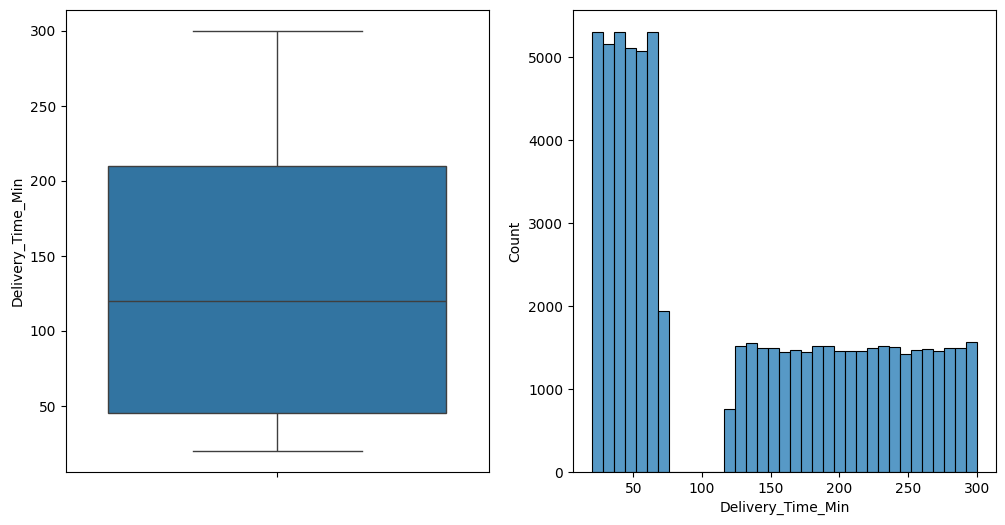

In [47]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
sns.boxplot(df["Delivery_Time_Min"])
plt.subplot(1,2,2)
sns.histplot(df["Delivery_Time_Min"], bins=35)
plt.show()

In [48]:
df["Delivery_Time_Min"].describe()

count    66641.000000
mean       127.475923
std         90.805839
min         20.000000
25%         45.000000
50%        120.000000
75%        210.000000
max        300.000000
Name: Delivery_Time_Min, dtype: float64

In [49]:
delivery_time = df.groupby(["City", "Restaurant_ID"])["Delivery_Time_Min"].median()

In [50]:
df["Delivery_Time_Min"] = df["Delivery_Time_Min"].fillna(
    df[["City", "Restaurant_ID",]].apply(tuple, axis=1).map(delivery_time)
)

In [51]:
df["Delivery_Time_Min"].describe()

count    100000.000000
mean        121.216945
std          79.962252
min          20.000000
25%          53.500000
50%         104.500000
75%         179.000000
max         300.000000
Name: Delivery_Time_Min, dtype: float64

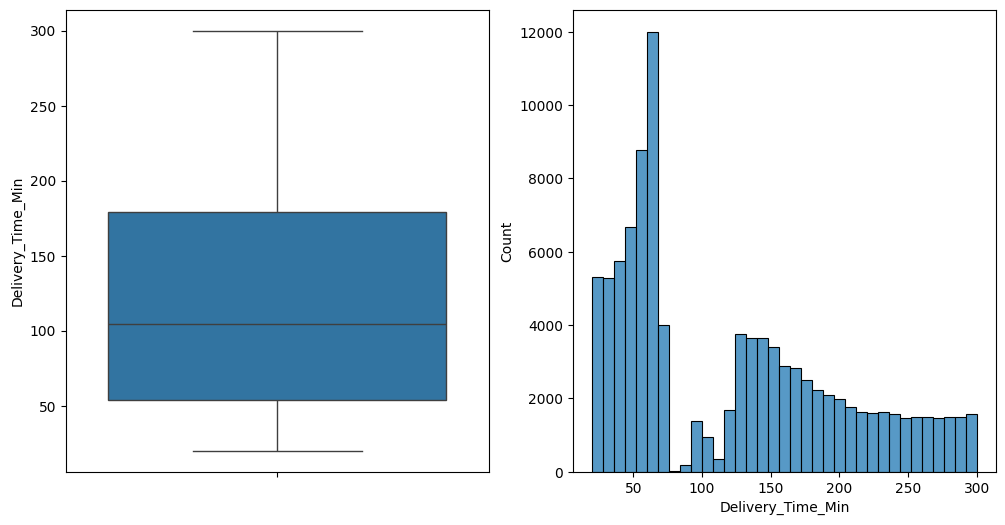

In [52]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
sns.boxplot(df["Delivery_Time_Min"])
plt.subplot(1,2,2)
sns.histplot(df["Delivery_Time_Min"], bins=35)
plt.show()

- Used two columns(`City` and `Restaurant_ID`) to extract median value from `Delivery_Time_Min` column to fill missing values.

### Distance_km - Null Imputation

In [53]:
df["Distance_km"].isnull().sum()

np.int64(33470)

In [54]:
df["Distance_km"].describe()

count    66530.000000
mean        16.449242
std         12.256742
min          1.000000
25%          5.470000
50%          9.970000
75%         27.430000
max         40.000000
Name: Distance_km, dtype: float64

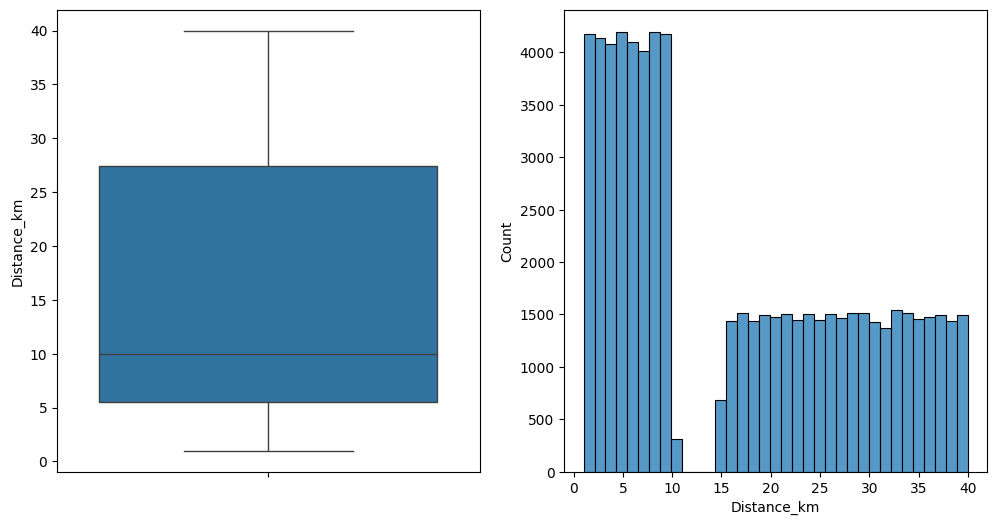

In [55]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
sns.boxplot(df["Distance_km"])
plt.subplot(1,2,2)
sns.histplot(df["Distance_km"], bins=35)
plt.show()

In [56]:
distance = df.groupby(["City","Area", "Restaurant_Name"])["Distance_km"].mean()
distance.dropna(inplace=True)

In [57]:
df["Distance_km"] = df["Distance_km"].fillna(
    df[["City","Area", "Restaurant_Name"]].apply(tuple, axis=1).map(distance)
)

In [58]:
df["Distance_km"].isnull().sum()

np.int64(248)

In [59]:
distance = df.groupby(["City","Area"])["Distance_km"].mean()

In [60]:
df["Distance_km"] = df["Distance_km"].fillna(
    df[["City","Area"]].apply(tuple, axis=1).map(distance)
)

In [61]:
df["Distance_km"].isnull().sum()

np.int64(0)

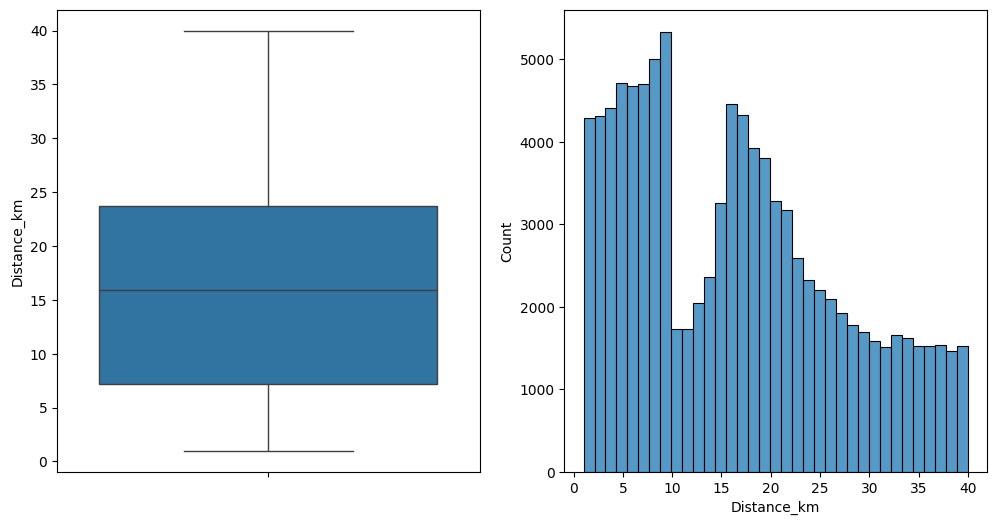

In [62]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
sns.boxplot(df["Distance_km"])
plt.subplot(1,2,2)
sns.histplot(df["Distance_km"], bins=35)
plt.show()

In [63]:
df["Distance_km"].isnull().sum()

np.int64(0)

1. Used three columns (`City`, `Area`, and `Restaurant_ID`) to compute the median of the `Distance_km` column and fill missing values.

2. After the first imputation step, `248` missing values were still present.

3. The remaining missing values were filled using the median based on (`City` and `Area`).


### Order_Value - Null Imputation

In [64]:
df["Order_Value"].isnull().sum()

np.int64(33327)

In [65]:
df["Order_Value"].describe()

count    66673.000000
mean      2081.830126
std       1553.628891
min        150.000000
25%        673.000000
50%       1197.000000
75%       3494.000000
max       5000.000000
Name: Order_Value, dtype: float64

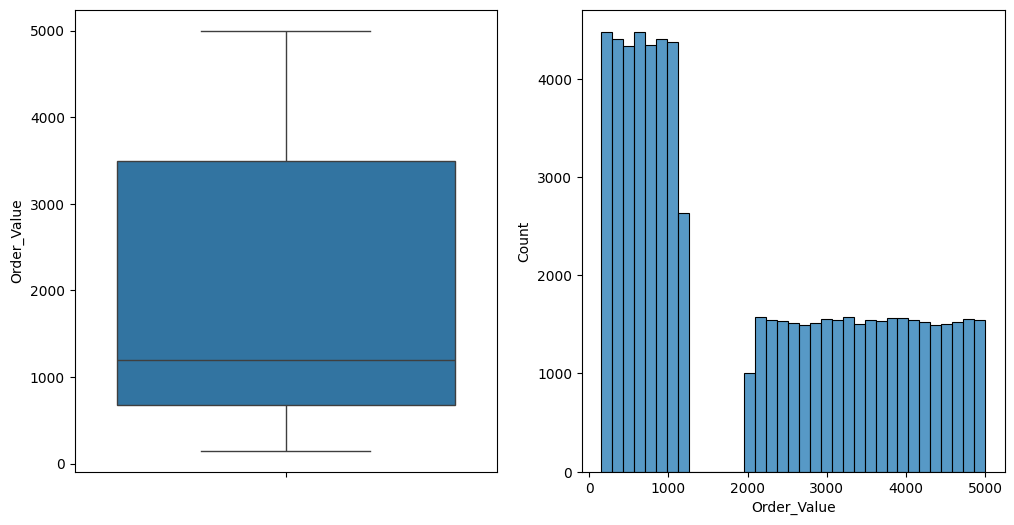

In [66]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
sns.boxplot(df["Order_Value"])
plt.subplot(1,2,2)
sns.histplot(df["Order_Value"], bins=35)
plt.show()

In [67]:
order_price = df.groupby(["City","Area", "Restaurant_Name"])["Order_Value"].mean()
order_price.dropna(inplace=True)

In [68]:
df["Order_Value"] = df["Order_Value"].fillna(
    df[["City","Area", "Restaurant_Name"]].apply(tuple, axis=1).map(order_price)
)

In [69]:
order_price = df.groupby(["City", "Area"])["Order_Value"].mean()

In [70]:
df["Order_Value"] = df["Order_Value"].fillna(
    df[["City", "Area"]].apply(tuple, axis=1).map(order_price)
)

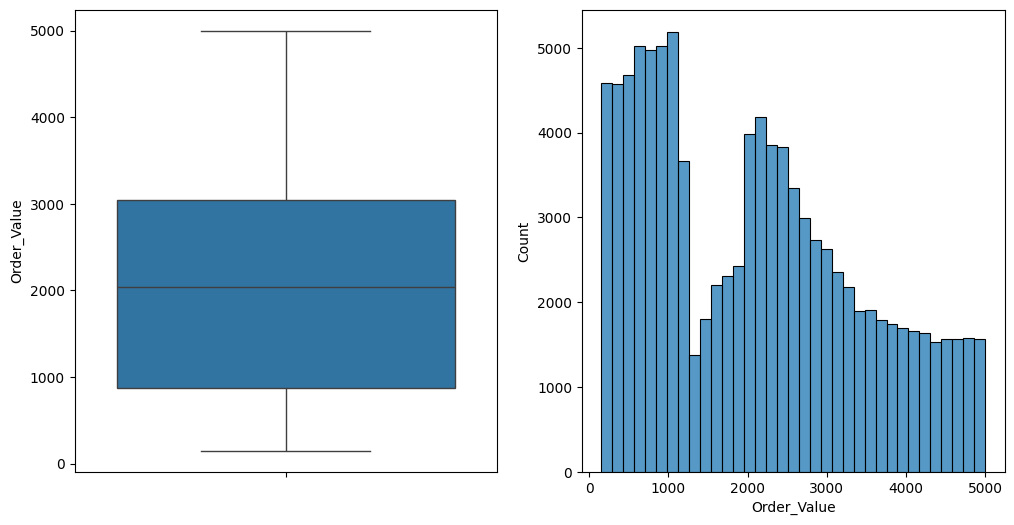

In [71]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
sns.boxplot(df["Order_Value"])
plt.subplot(1,2,2)
sns.histplot(df["Order_Value"], bins=35)
plt.show()

In [72]:
df["Order_Value"].isnull().sum()

np.int64(0)

1. Used three columns (`City`, `Area`, and `Restaurant_ID`) to compute the mean of the `Order_Value` column and fill missing values.

2. After the first imputation step missing values were still present.

3. The remaining missing values were filled using the mean based on (`City` and `Area`).


### Discount_Applied - Null Imputation

In [73]:
df["Discount_Applied"].isnull().sum()

np.int64(16715)

In [74]:
df["Discount_Applied"].describe()

count    83285.000000
mean        93.936243
std        108.209904
min          0.000000
25%         20.000000
50%         50.000000
75%        100.000000
max        300.000000
Name: Discount_Applied, dtype: float64

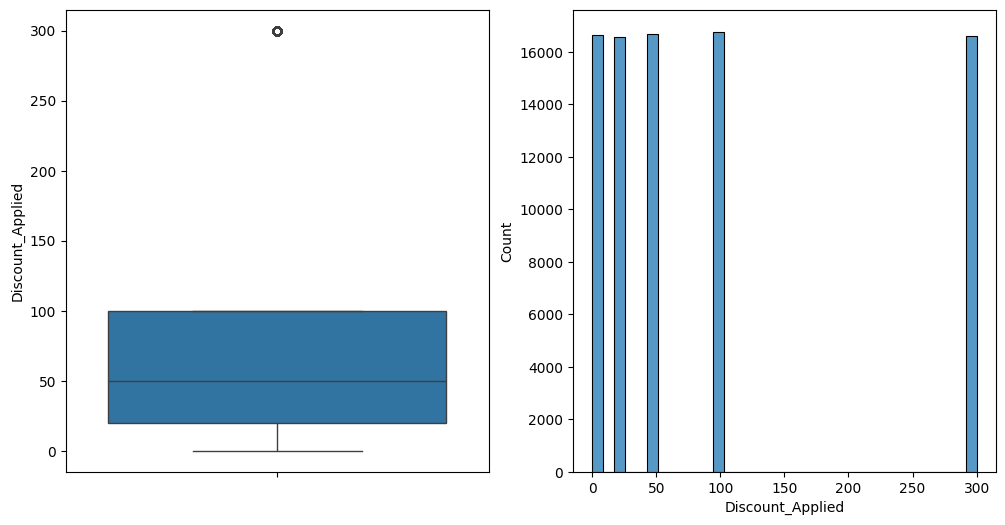

In [75]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
sns.boxplot(df["Discount_Applied"])
plt.subplot(1,2,2)
sns.histplot(df["Discount_Applied"], bins=35)
plt.show()

In [76]:
discount_price = df.groupby(["City","Area", "Restaurant_Name"])["Discount_Applied"].median()
discount_price.dropna(inplace=True)

In [77]:
df["Discount_Applied"] = df["Discount_Applied"].fillna(
    df[["City","Area", "Restaurant_Name"]].apply(tuple, axis=1).map(discount_price)
)

In [78]:
df["Discount_Applied"].isnull().sum()

np.int64(39)

In [79]:
discount_price = df.groupby(["City","Area"])["Discount_Applied"].median()

In [80]:
df["Discount_Applied"] = df["Discount_Applied"].fillna(
    df[["City","Area"]].apply(tuple, axis=1).map(discount_price)
)

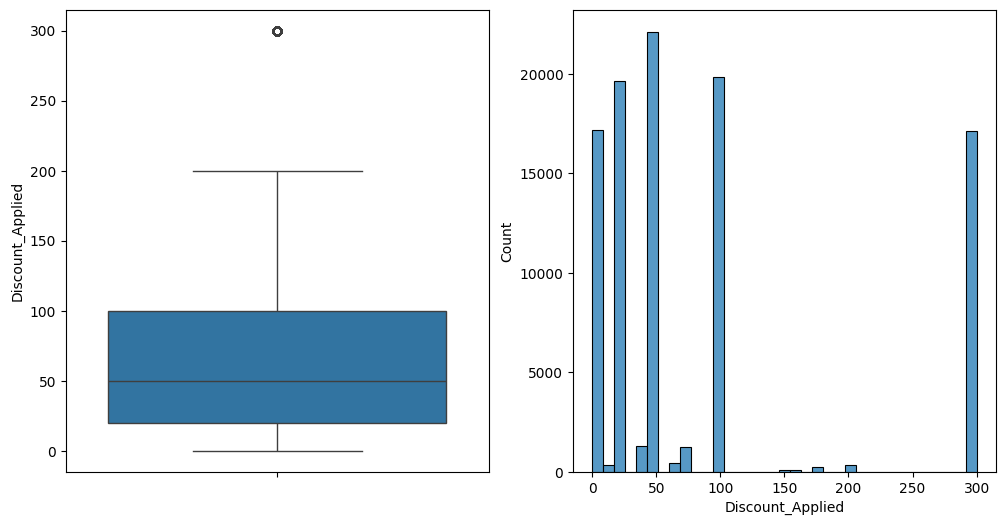

In [81]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
sns.boxplot(df["Discount_Applied"])
plt.subplot(1,2,2)
sns.histplot(df["Discount_Applied"], bins=35)
plt.show()

In [82]:
df["Discount_Applied"].isnull().sum()

np.int64(0)

1. Used three columns (`City`, `Area`, and `Restaurant_ID`) to compute the median of the `Discount_Applied` column and fill missing values.

2. After the first imputation step missing values were still present.

3. The remaining missing values were filled using the median based on (`City` and `Area`).


### Final_Amount - Null Imputation

In [83]:
df["Final_Amount"].isnull().sum()

np.int64(55697)

In [84]:
df["Final_Amount"] = df["Final_Amount"].fillna(df["Order_Value"] - df["Discount_Applied"])

In [85]:
df["Final_Amount"].isnull().sum()

np.int64(0)

- `Final_Amount` were calculated using `Order_Value` and `Discount_Applied`.

### Payment_Mode - Null Imputation

In [86]:
df["Payment_Mode"].isnull().sum()

np.int64(19911)

In [87]:
df["Payment_Mode"].value_counts()

Payment_Mode
Card      20094
Wallet    20086
COD       19977
UPI       19932
Name: count, dtype: int64

In [88]:
payment_mode = df.groupby(["City", "Area"])["Payment_Mode"].agg(lambda x: x.mode()[0])

In [89]:
df["Payment_Mode"] = df["Payment_Mode"].fillna(
    df[["City", "Area"]].apply(tuple, axis=1).map(payment_mode)
)

In [90]:
df["Payment_Mode"].value_counts()

Payment_Mode
Wallet    27937
Card      24787
UPI       24641
COD       22635
Name: count, dtype: int64

- * Used `City` and `Area` columns to find the most frequent value in `Payment_Mode` and filled the missing values.


### Cancellation_Reason - Null Imputation

#### Filling Null values with `Delivered` Where `Order_Status` is `Delivered`.

In [91]:
condition = (df["Order_Status"] == "Delivered")

In [92]:
df.loc[condition, "Cancellation_Reason"] = "Order Delivered"

In [93]:
df["Cancellation_Reason"].value_counts()

Cancellation_Reason
Order Delivered       84964
Late Delivery          3059
Customer Cancelled     2993
Restaurant Issue       2979
Name: count, dtype: int64

#### Filling Null values with `Late Delivery` => `Delivery_Time` >= 120 and `Distance_km` <= 40

In [94]:
condition = (
    (df["Cancellation_Reason"].isnull()) &
    (df["Delivery_Time_Min"] >= 120) & 
    (df["Distance_km"] <= 40)
)

In [95]:
df.loc[condition, "Cancellation_Reason"] = "Late Delivery"

In [96]:
df["Cancellation_Reason"].isnull().sum()

np.int64(3080)

In [97]:
df["Cancellation_Reason"].value_counts()

Cancellation_Reason
Order Delivered       84964
Late Delivery          5984
Customer Cancelled     2993
Restaurant Issue       2979
Name: count, dtype: int64

#### Filling Null values with `Customer Cancelled` => `Delivery_Time` >= 50 and `Distance_km` <= 20

In [98]:
condition = (
    (df["Cancellation_Reason"].isnull()) &
    (df["Delivery_Time_Min"] >= 50) & 
    (df["Distance_km"] <= 20)
)

In [99]:
df.loc[condition, "Cancellation_Reason"] = "Customer Cancelled"

In [100]:
df["Cancellation_Reason"].isnull().sum()

np.int64(1929)

In [101]:
df["Cancellation_Reason"].value_counts()

Cancellation_Reason
Order Delivered       84964
Late Delivery          5984
Customer Cancelled     4144
Restaurant Issue       2979
Name: count, dtype: int64

#### Filling Null values with `Restaurant Issue` => For Remaining Records

In [102]:
df["Cancellation_Reason"] = df["Cancellation_Reason"].fillna("Restaurant Issue")

In [103]:
df["Cancellation_Reason"].isnull().sum()

np.int64(0)

In [104]:
df["Cancellation_Reason"].value_counts()

Cancellation_Reason
Order Delivered       84964
Late Delivery          5984
Restaurant Issue       4908
Customer Cancelled     4144
Name: count, dtype: int64

### Delivery_Rating - Null Imputation

#### Filling `Delivery_Rating` = 0,  Where `Order_Status` is `Cancelled`.

In [105]:
df["Delivery_Rating"].isnull().sum()

np.int64(16523)

In [106]:
condition = (
    (df["Delivery_Rating"].isnull()) & 
    (df["Order_Status"] == "Cancelled")
)

df.loc[condition, "Delivery_Rating"] = 0

In [107]:
condition = (df["Order_Status"] == "Cancelled")

df.loc[condition, "Delivery_Rating"] = 0

In [108]:
df["Delivery_Rating"].isnull().sum()

np.int64(14048)

In [109]:
df["Delivery_Rating"].value_counts()

Delivery_Rating
0.0    15036
2.0    14377
4.0    14375
1.0    14292
5.0    14007
3.0    13865
Name: count, dtype: int64

In [110]:
df["Delivery_Rating"].isnull().sum()

np.int64(14048)

#### Filling missing values in `Delivery_Rating` => Based on `Delivery_Partner_ID`

In [111]:
delivery_rating = round(df.groupby("Delivery_Partner_ID")["Delivery_Rating"].mean())

In [112]:
df["Delivery_Rating"] = df["Delivery_Rating"].fillna(
    df["Delivery_Partner_ID"].map(delivery_rating)
)

In [113]:
df["Delivery_Rating"] = df["Delivery_Rating"].astype(int)

In [114]:
df["Delivery_Rating"].value_counts()

Delivery_Rating
2    22401
3    19889
0    15036
4    14375
1    14292
5    14007
Name: count, dtype: int64

In [115]:
df["Delivery_Rating"].isnull().sum()

np.int64(0)

### Peak_Hour - Null Imputation

In [116]:
df["Peak_Hour"].isnull().sum()

np.int64(32962)

In [117]:
df["Peak_Hour"].value_counts()

Peak_Hour
False    33585
True     33453
Name: count, dtype: int64

In [118]:
df["Peak_Hour"] = df["Peak_Hour"].ffill()

In [119]:
df["Peak_Hour"].value_counts()

Peak_Hour
False    50154
True     49846
Name: count, dtype: int64

- Since `Time` column not available, Missing values in `Peak_Hour` filled using `forward fill`.

In [120]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Order_ID             100000 non-null  str           
 1   Customer_ID          100000 non-null  str           
 2   Customer_Age         100000 non-null  float64       
 3   Customer_Gender      100000 non-null  str           
 4   City                 100000 non-null  str           
 5   Area                 100000 non-null  str           
 6   Restaurant_ID        100000 non-null  str           
 7   Restaurant_Name      100000 non-null  str           
 8   Cuisine_Type         100000 non-null  str           
 9   Order_Date           100000 non-null  datetime64[us]
 10  Delivery_Time_Min    100000 non-null  float64       
 11  Distance_km          100000 non-null  float64       
 12  Order_Value          100000 non-null  float64       
 13  Discount_Applied     10000

- Null Imputation completed for all columns.

## Check For Outliers

In [121]:
numeric_columns = []

for column in df.columns:
    if (df[column].dtype != "str" and 
        df[column].dtype != "object" and 
        df[column].dtype != "datetime64[us]"
    ):

        numeric_columns.append(column)

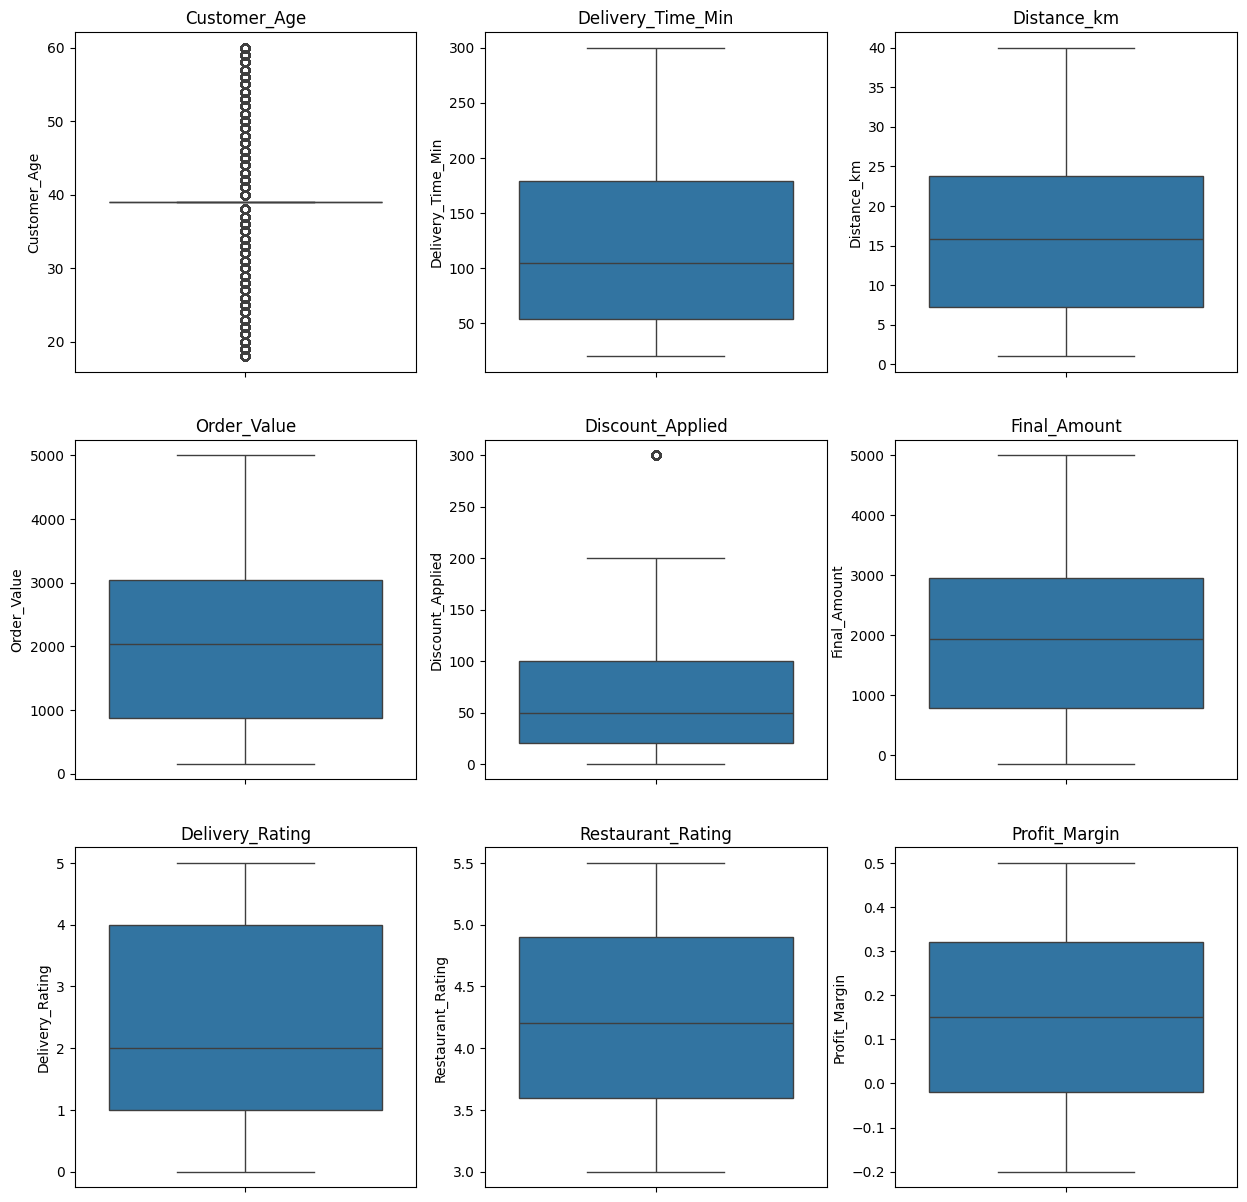

In [122]:
plt.figure(figsize=(15, 15))


for i, column in enumerate(numeric_columns, 1):

    plt.subplot(3, 3, i)
    sns.boxplot(df[column])
    plt.title(column)

plt.show()

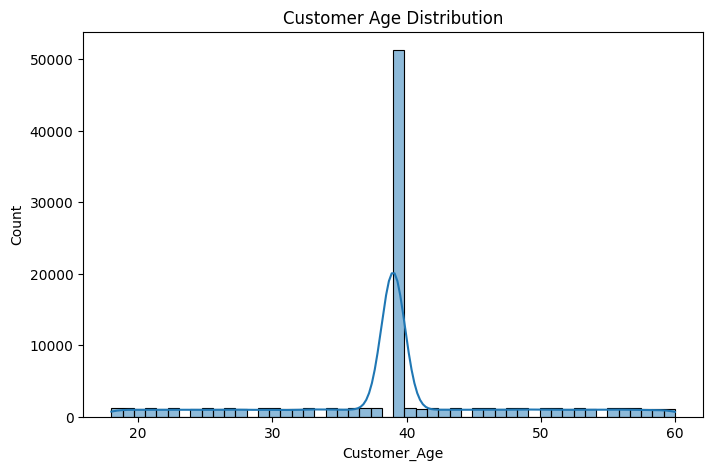

In [123]:
plt.figure(figsize=(8,5))

sns.histplot(df["Customer_Age"], bins=50, kde=True)

plt.title("Customer Age Distribution")

plt.show()

- It may show some outliers in the `Age` column, but these values are not treated as actual `outliers` because they represent realistic human ages.


### Cleaning Negative Values in Profit Margin

In [124]:
df["Profit_Margin"][df["Profit_Margin"] < 0].count()

np.int64(27733)

In [125]:
df["Profit_Margin"][df["Profit_Margin"] < 0].value_counts().sort_values()

Profit_Margin
-0.20     732
-0.13    1379
-0.12    1390
-0.05    1392
-0.16    1394
-0.02    1400
-0.10    1401
-0.07    1402
-0.04    1408
-0.14    1412
-0.17    1425
-0.08    1427
-0.03    1432
-0.15    1435
-0.06    1436
-0.09    1437
-0.11    1444
-0.18    1453
-0.19    1458
-0.01    1476
Name: count, dtype: int64

In [126]:
df["Profit_Margin"] = abs(df["Profit_Margin"])

In [127]:
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,Hyderabad,Central,RES936,Restaurant_29,Chinese,2024-10-20,187.0,15.75,2847.50,0.0,2847.50,UPI,Delivered,Order Delivered,DP563,5,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,20.0,29.50,4869.00,20.0,4849.00,COD,Delivered,Order Delivered,DP369,5,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,39.0,Male,Delhi,East,RES723,Restaurant_244,Arabian,2024-12-08,207.0,20.41,757.00,20.0,737.00,Wallet,Delivered,Order Delivered,DP580,4,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,143.0,15.68,2283.25,50.0,2233.25,UPI,Cancelled,Late Delivery,DP155,0,3.4,Weekday,True,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,51.0,9.60,372.00,20.0,352.00,Card,Delivered,Order Delivered,DP728,2,4.4,Weekend,False,0.12


### Standardizing categorical values

In [128]:
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,Hyderabad,Central,RES936,Restaurant_29,Chinese,2024-10-20,187.0,15.75,2847.50,0.0,2847.50,UPI,Delivered,Order Delivered,DP563,5,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,20.0,29.50,4869.00,20.0,4849.00,COD,Delivered,Order Delivered,DP369,5,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,39.0,Male,Delhi,East,RES723,Restaurant_244,Arabian,2024-12-08,207.0,20.41,757.00,20.0,737.00,Wallet,Delivered,Order Delivered,DP580,4,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,143.0,15.68,2283.25,50.0,2233.25,UPI,Cancelled,Late Delivery,DP155,0,3.4,Weekday,True,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,51.0,9.60,372.00,20.0,352.00,Card,Delivered,Order Delivered,DP728,2,4.4,Weekend,False,0.12


In [129]:
category_columns = ['Customer_Gender', 'City', 'Area', 'Cuisine_Type', 
                    'Payment_Mode', 'Order_Status', 'Cancellation_Reason', 
                    'Order_Day', 'Peak_Hour' ]

In [130]:
for column in category_columns:
    print(df[column].value_counts())
    print()

Customer_Gender
Other     33503
Female    33261
Male      33236
Name: count, dtype: int64

City
Bangalore    20718
Hyderabad    20273
Delhi        20010
Chennai      19519
Mumbai       19480
Name: count, dtype: int64

Area
East       23385
South      20119
West       19977
North      19900
Central    16619
Name: count, dtype: int64

Cuisine_Type
Arabian    21192
Chinese    20389
Indian     19763
Italian    19511
Mexican    19145
Name: count, dtype: int64

Payment_Mode
Wallet    27937
Card      24787
UPI       24641
COD       22635
Name: count, dtype: int64

Order_Status
Delivered    84964
Cancelled    15036
Name: count, dtype: int64

Cancellation_Reason
Order Delivered       84964
Late Delivery          5984
Restaurant Issue       4908
Customer Cancelled     4144
Name: count, dtype: int64

Order_Day
Weekday    71370
Weekend    28630
Name: count, dtype: int64

Peak_Hour
False    50154
True     49846
Name: count, dtype: int64



- Standardization is not required for the categorical columns because none of them contain duplicate values.

## Cleaning Restaurnat Rating Features

In [134]:
df.loc[df['Restaurant_Rating'] > 5, 'Restaurant_Rating'] = 5

# Storing CSV file

In [137]:
df.isnull().sum()

Order_ID               0
Customer_ID            0
Customer_Age           0
Customer_Gender        0
City                   0
Area                   0
Restaurant_ID          0
Restaurant_Name        0
Cuisine_Type           0
Order_Date             0
Delivery_Time_Min      0
Distance_km            0
Order_Value            0
Discount_Applied       0
Final_Amount           0
Payment_Mode           0
Order_Status           0
Cancellation_Reason    0
Delivery_Partner_ID    0
Delivery_Rating        0
Restaurant_Rating      0
Order_Day              0
Peak_Hour              0
Profit_Margin          0
dtype: int64

In [138]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Order_ID             100000 non-null  str           
 1   Customer_ID          100000 non-null  str           
 2   Customer_Age         100000 non-null  float64       
 3   Customer_Gender      100000 non-null  str           
 4   City                 100000 non-null  str           
 5   Area                 100000 non-null  str           
 6   Restaurant_ID        100000 non-null  str           
 7   Restaurant_Name      100000 non-null  str           
 8   Cuisine_Type         100000 non-null  str           
 9   Order_Date           100000 non-null  datetime64[us]
 10  Delivery_Time_Min    100000 non-null  float64       
 11  Distance_km          100000 non-null  float64       
 12  Order_Value          100000 non-null  float64       
 13  Discount_Applied     10000

In [139]:
df.to_csv("../csv_files/online_food_delivery_cleaned.csv", index=False)